### 분석 라이브러리 로드 및 사용 준비하기

In [16]:
import geopandas as gpd # 지리정보 파일 읽고 처리 # Anaconda Prompt에서 pip install geopandas로 설치해야 함
import pandas as pd # 표 형식 데이터 처리
import matplotlib.pyplot as plt # 그래프, 지도 등 시각화

In [17]:
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우에서 한글 폰트 설정

### 부산시 경계, 격자 경계 및 통계 데이터 불러오기

In [18]:
prj_dir = 'C:/Users/user/Desktop/sgis-data-manual/공간분석 사례 Case Studies/Python/부산시 인구 격자별 분석' # 'C:/SGIS/Python/부산시 인구 격자별 분석'
bord_sido = gpd.read_file(prj_dir + '/' + 'bnd_sido_21_2025_2Q.shp') # gpd.read_file(prj_dir + '/' + 'bnd_sido_21_2024_2Q.shp')
grid_mara = gpd.read_file(prj_dir + '/' + 'grid_마라_1K.shp')
grid_mama = gpd.read_file(prj_dir + '/' + 'grid_마마_1K.shp')
stat_mara = pd.read_csv(prj_dir + '/' + '2024년_인구_마라_1K.csv', encoding='CP949', # pd.read_csv(prj_dir + '/' + '2023년_인구_마라_1K.csv', encoding='CP949',
                   names=['BASE_YEAR', 'GRID_1K_CD', 'STAT_CD', 'POP'])
stat_mama = pd.read_csv(prj_dir + '/' + '2024년_인구_마마_1K.csv', encoding='CP949', # pd.read_csv(prj_dir + '/' + '2023년_인구_마마_1K.csv', encoding='CP949',
                   names=['BASE_YEAR', 'GRID_1K_CD', 'STAT_CD', 'POP'])

### 격자 통계 및 통계 데이터 병합하기

In [19]:
grid_merged = pd.concat([grid_mara, grid_mama], ignore_index=True)
stat_merged = pd.concat([stat_mara, stat_mama], ignore_index=True)

### 데이터 구조 확인하기

In [20]:
grid_merged = grid_merged.rename(columns={'GRID_CD': 'GRID_1K_CD'})

In [21]:
print(grid_merged.info()) # 격자 경계 코드(GRID_1K_CD), 지리정보(geometry)로 구성
print(stat_merged.info()) # 기준날짜(BASE_YEAR), 격자 경계 코드(GRID_1K_CD), 통계 코드(STAT_CD), 인구수(POP)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   GRID_1K_CD  9551 non-null   object  
 1   geometry    9551 non-null   geometry
dtypes: geometry(1), object(1)
memory usage: 149.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260662 entries, 0 to 260661
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   BASE_YEAR   260662 non-null  int64 
 1   GRID_1K_CD  260662 non-null  object
 2   STAT_CD     260662 non-null  object
 3   POP         260662 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 8.0+ MB
None


### 통계 항목 필터링

In [22]:
# STAT_CD 열에 있는 고유 값 확인
unique_stat_cd = stat_merged['STAT_CD'].unique()
print(unique_stat_cd)

['in_age_005' 'in_age_006' 'in_age_007' 'in_age_008' 'in_age_011'
 'in_age_012' 'in_age_013' 'in_age_014' 'in_age_015' 'in_age_016'
 'in_age_017' 'in_age_035' 'in_age_036' 'in_age_037' 'in_age_041'
 'in_age_042' 'in_age_043' 'in_age_044' 'in_age_045' 'in_age_046'
 'in_age_047' 'in_age_066' 'in_age_068' 'in_age_071' 'in_age_073'
 'in_age_074' 'in_age_075' 'in_age_076' 'in_age_077' 'to_in_001'
 'to_in_007' 'to_in_008' 'in_age_003' 'in_age_004' 'in_age_009'
 'in_age_010' 'in_age_018' 'in_age_019' 'in_age_020' 'in_age_034'
 'in_age_038' 'in_age_039' 'in_age_040' 'in_age_048' 'in_age_063'
 'in_age_064' 'in_age_070' 'in_age_072' 'in_age_078' 'in_age_079'
 'in_age_080' 'in_age_033' 'in_age_065' 'in_age_069' 'in_age_002'
 'in_age_062' 'in_age_067' 'in_age_032' 'in_age_049' 'in_age_001'
 'in_age_061' 'in_age_031' 'in_age_050' 'in_age_021' 'in_age_081'
 'in_age_051']


In [23]:
# 총인구('to_in_001') 데이터만 필터링
stat_total = stat_merged[stat_merged['STAT_CD'] == 'to_in_001']

# 필터링 후 STAT_CD 고유값 재확인
unique_stat_cd = stat_total['STAT_CD'].unique()
print(unique_stat_cd)

['to_in_001']


### 분석에 필요한 컬럼만 선택하기

In [24]:
stat_total = stat_total[['GRID_1K_CD', 'POP']]

### 부산시 경계와 격자 경계가 교차하는 격자만 선택하기

In [25]:
grid_intersects = grid_merged[grid_merged.geometry.intersects(bord_sido.geometry.union_all())]

### 경계와 통계 병합하기

In [26]:
grid_intersects = grid_intersects.merge(stat_total, on='GRID_1K_CD', how='left')
# 결합 후 통계값이 없는 구간에 NaN이 들어가 있을 수 있음(결측값 확인)
print(grid_intersects.isna().sum())

GRID_1K_CD      0
geometry        0
POP           238
dtype: int64


In [27]:
# 결측값을 0으로 채우기
grid_intersects['POP'] = grid_intersects['POP'].fillna(0)

### 총인구수를 기준으로 구간 나누기

In [29]:
# 인구 구간 직접 지정하여 나누기
print(grid_intersects['POP'].min(), grid_intersects['POP'].max()) # 최소값과 최대값 확인

0.0 31259.0


In [30]:
bins = [0, 1000, 5000, 10000, 20000, 32000] # 적절한 구간 지정
labels = ['0~1000', '1000~5000', '5000~10,000', '10,000~20,000', '20,000~32,000'] # 구간의 라벨
# 각 인구 수에 대해 구간 할당
grid_intersects['POP_BINS'] = pd.cut(grid_intersects['POP'], bins=bins, labels=labels, right=False)
print(grid_intersects.head()) # 인구 구간('POP_BINS') 컬럼 추가 확인

  GRID_1K_CD                                           geometry  POP POP_BINS
0     마라1569  POLYGON ((1115000 1669000, 1115000 1670000, 11...  0.0   0~1000
1     마라1668  POLYGON ((1116000 1668000, 1116000 1669000, 11...  0.0   0~1000
2     마라1669  POLYGON ((1116000 1669000, 1116000 1670000, 11...  0.0   0~1000
3     마라1773  POLYGON ((1117000 1673000, 1117000 1674000, 11...  0.0   0~1000
4     마라1774  POLYGON ((1117000 1674000, 1117000 1675000, 11...  0.0   0~1000


### 지도 시각화 하기

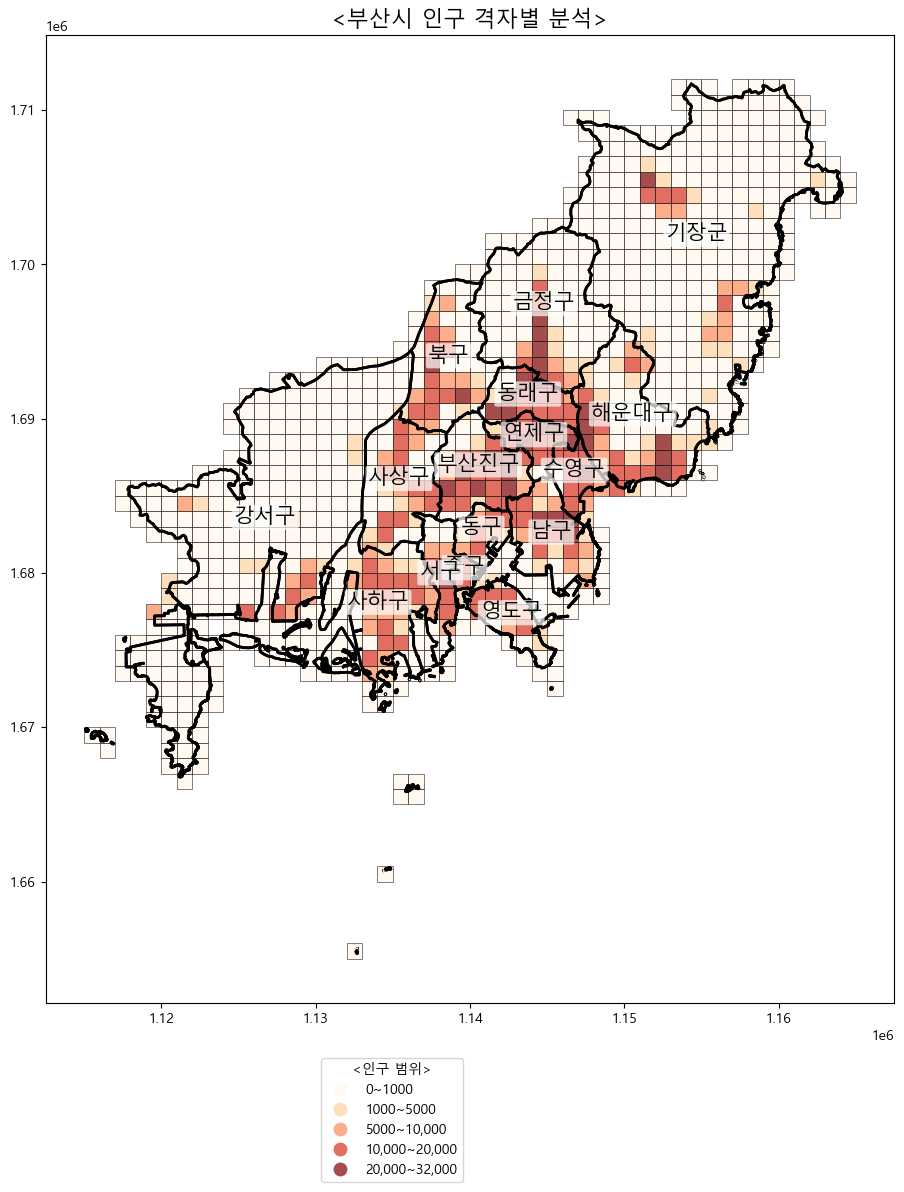

In [31]:
# 시각화 설정(그림과 축 설정)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 격자 시각화(격자 경계 선은 연하게 설정)
grid_intersects.plot(column='POP_BINS', ax=ax, legend=True, cmap='OrRd', edgecolor='black', linewidth=0.5, alpha=0.7)

# 부산시 경계 추가(경계선만 보이도록 설정, 배경은 투명)
bord_sido.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

# (추가) 서울시 시군구 경계를 추가하여 명확하게 분석하기
bord_sgg = gpd.read_file(prj_dir + '/' + 'bnd_sigungu_21_2025_2Q.shp') # gpd.read_file(prj_dir + '/' + 'bnd_sigungu_21_2024_2Q.shp')
bord_sgg.plot(ax=ax, color='none', edgecolor='black', linewidth=2)
bord_sgg['centroid'] = bord_sgg.geometry.centroid # 중심점 계산
for idx, row in bord_sgg.iterrows():
    ax.text(row['centroid'].x, row['centroid'].y, row['SIGUNGU_NM'],
            fontsize=15, ha='center', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.1'))

# 범례 위치 및 제목 설정
ax.get_legend().set_bbox_to_anchor((0.5, -0.05)) # 범례 위치 조정
ax.get_legend().set_title("<인구 범위>") # 범례 제목 설정
ax.set_title('<부산시 인구 격자별 분석>', fontsize=16) # 지도 제목 설정

# 레이아웃 조정 및 출력
plt.tight_layout() # 그래프 레이아웃이 겹치지 않도록 자동 조정
plt.savefig(prj_dir + '/' + '부산시 인구 격자별 분석 지도.png')
plt.show() # 시각화 결과 화면에 출력